# Cell 1 — Setup

In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import pyogrio
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
# -------------------------------------------------------------------
# INPUT BROAD KNN POINT LAYER
# -------------------------------------------------------------------
knn_folder = r"E:\World Bank deliverbale 1\knn"

in_gpkg = os.path.join(
    knn_folder,
    "buildings_points_knn_metrics_broad.gpkg"
)

in_layer = "wb_buildings_extent_point_knn_broad"

# -------------------------------------------------------------------
# OUTPUTS
# -------------------------------------------------------------------
out_gpkg = os.path.join(
    knn_folder,
    "buildings_points_knn_kmeans_broad_compact.gpkg"
)

profile_folder = os.path.join(
    knn_folder,
    "kmeans_profiles_broad_compact"
)

os.makedirs(profile_folder, exist_ok=True)

print("Input:", in_gpkg)
print("Layer:", in_layer)
print("Output:", out_gpkg)
print("Profile folder:", profile_folder)

Input: E:\World Bank deliverbale 1\knn\buildings_points_knn_metrics_broad.gpkg
Layer: wb_buildings_extent_point_knn_broad
Output: E:\World Bank deliverbale 1\knn\buildings_points_knn_kmeans_broad_compact.gpkg
Profile folder: E:\World Bank deliverbale 1\knn\kmeans_profiles_broad_compact


# Cell 2 — Read the broad NN layer

In [3]:
print(pyogrio.list_layers(in_gpkg))

[['wb_buildings_extent_point_knn_broad' 'Point']]


In [4]:
gdf = pyogrio.read_dataframe(in_gpkg, layer=in_layer)

print("Rows:", f"{len(gdf):,}")
print("Columns:")
print(gdf.columns.tolist())
print("CRS:", gdf.crs)

gdf.head()

Rows: 578,379
Columns:
['type', 'building', 'construction', 'area_m_utm', 'ORIG_FID', 'd5_near', 'd80_near', 'r80_5', 'd500_near', 'd1000_near', 'd2000_near', 'd4000_near', 'd8000_near', 'r500_80', 'r1000_80', 'r2000_80', 'r4000_80', 'r8000_80', 'd500_near_q4', 'd1000_near_q4', 'd2000_near_q4', 'd4000_near_q4', 'd8000_near_q4', 'r8000_80_q4', 'geometry']
CRS: EPSG:32636


,type,building,construction,area_m_utm,ORIG_FID,d5_near,d80_near,r80_5,d500_near,d1000_near,...,r2000_80,r4000_80,r8000_80,d500_near_q4,d1000_near_q4,d2000_near_q4,d4000_near_q4,d8000_near_q4,r8000_80_q4,geometry
0,multipolygon,yes,None,297.854874,1,24.751932,139.705179,5.644213,298.442495,423.718285,...,3.911436,4.898739,6.610803,4,4,4,3,3,1,POINT (344402.388 536236.527)
1,multipolygon,yes,None,134.675182,2,13.947397,85.227719,6.110654,208.683046,298.791597,...,4.962366,6.933047,9.663992,3,3,3,3,2,1,POINT (343156.5 537298.568)
2,multipolygon,yes,None,254.245943,3,16.169194,64.679283,4.000155,180.006642,250.973065,...,5.616097,8.103348,11.935480,2,2,2,2,2,3,POINT (343313.65 538071.93)
3,multipolygon,yes,None,331.438943,4,34.483712,113.930039,3.303880,267.846031,371.916636,...,4.316094,5.718465,9.315104,4,3,3,3,3,1,POINT (346336.899 536569.205)
4,multipolygon,yes,None,431.678814,5,37.518905,139.469801,3.717321,258.271489,325.549845,...,3.181445,4.681121,7.048470,3,3,3,3,3,1,POINT (343792.458 541426.962)


In [5]:
required_fields = [
    "d20_near",
    "d80_near",
    "d500_near",
    "d2000_near",
    "d8000_near",
    "r8000_80",
]

missing = [c for c in required_fields if c not in gdf.columns]
print("Missing fields:", missing)

if missing:
    raise ValueError(f"Missing required fields: {missing}")

Missing fields: ['d20_near']


ValueError: Missing required fields: ['d20_near']

In [6]:
summary_csv_folder = os.path.join(knn_folder, "summary_csvs")
wide_csv = os.path.join(summary_csv_folder, "knn_summary_all_k_wide.csv")

wide = pd.read_csv(wide_csv)

d20 = wide[["building_id", "dist_to_20th_neighbor"]].copy()
d20 = d20.rename(columns={"dist_to_20th_neighbor": "d20_near"})

d20["building_id"] = pd.to_numeric(d20["building_id"], errors="coerce").astype("Int64")
gdf["ORIG_FID"] = pd.to_numeric(gdf["ORIG_FID"], errors="coerce").astype("Int64")

if "d20_near" in gdf.columns:
    gdf = gdf.drop(columns=["d20_near"])

gdf = gdf.merge(
    d20,
    left_on="ORIG_FID",
    right_on="building_id",
    how="left",
    validate="one_to_one"
)

print("Rows after join:", f"{len(gdf):,}")
print("Matched d20:", f"{gdf['d20_near'].notna().sum():,}")

Rows after join: 578,379
Matched d20: 578,379


# Cell 3 — Create log variables for compact model

In [7]:
km_gdf = gdf.copy()

# Ensure numeric
raw_cols = [
    "d20_near",
    "d80_near",
    "d500_near",
    "d2000_near",
    "d8000_near",
    "r8000_80",
]

for col in raw_cols:
    km_gdf[col] = pd.to_numeric(km_gdf[col], errors="coerce")

# Log transform
# All these should be positive. If any zeros/nulls exist, they will become invalid.
km_gdf["log_d20"] = np.log(km_gdf["d20_near"])
km_gdf["log_d80"] = np.log(km_gdf["d80_near"])
km_gdf["log_d500"] = np.log(km_gdf["d500_near"])
km_gdf["log_d2000"] = np.log(km_gdf["d2000_near"])
km_gdf["log_d8000"] = np.log(km_gdf["d8000_near"])
km_gdf["log_r8000_80"] = np.log(km_gdf["r8000_80"])

feature_cols = [
    "log_d20",
    "log_d80",
    "log_d500",
    "log_d2000",
    "log_d8000",
    "log_r8000_80",
]

# Valid rows
valid_mask = (
    km_gdf[feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .notna()
    .all(axis=1)
)

print("Total rows:", f"{len(km_gdf):,}")
print("Valid rows:", f"{valid_mask.sum():,}")
print("Invalid rows:", f"{len(km_gdf) - valid_mask.sum():,}")

X = km_gdf.loc[valid_mask, feature_cols].copy()

X.describe()

Total rows: 578,379
Valid rows: 578,379
Invalid rows: 0


,log_d20,log_d80,log_d500,log_d2000,log_d8000,log_r8000_80
count,578379.000000,578379.000000,578379.000000,578379.000000,578379.000000,578379.000000
mean,3.696497,4.427088,5.384682,6.119739,6.852878,2.425790
std,0.423786,0.408473,0.394562,0.389313,0.354592,0.270947
min,1.972484,3.171742,4.225400,5.342283,6.309636,0.721992
25%,3.427586,4.172514,5.135106,5.864589,6.596644,2.286147
50%,3.629248,4.342148,5.287689,6.001488,6.737039,2.403404
75%,3.909254,4.614754,5.557348,6.280471,7.013974,2.542495
max,6.738560,7.212494,7.956560,8.611861,8.897565,4.411551


# Cell 4 — Standardize features

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=feature_cols,
    index=X.index
)

X_scaled_df.describe()

,log_d20,log_d80,log_d500,log_d2000,log_d8000,log_r8000_80
count,5.783790e+05,5.783790e+05,5.783790e+05,5.783790e+05,5.783790e+05,5.783790e+05
mean,1.231456e-16,2.088462e-16,4.601496e-16,-5.546464e-16,-8.486527e-17,-4.226065e-16
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,-4.068124e+00,-3.073268e+00,-2.938148e+00,-1.996997e+00,-1.532023e+00,-6.288312e+00
25%,-6.345452e-01,-6.232332e-01,-6.325399e-01,-6.553855e-01,-7.226185e-01,-5.153916e-01
50%,-1.586869e-01,-2.079438e-01,-2.458242e-01,-3.037422e-01,-3.266829e-01,-8.262341e-02
75%,5.020382e-01,4.594350e-01,4.376144e-01,4.128605e-01,4.543149e-01,4.307283e-01
max,7.178306e+00,6.819077e+00,6.518310e+00,6.401340e+00,5.766315e+00,7.328965e+00


# Cell 5 — Test candidate k values

In [10]:
k_candidates = range(2, 7)

inertias = []
silhouettes = []

silhouette_sample_size = 50_000

if len(X_scaled_df) > silhouette_sample_size:
    X_sil = X_scaled_df.sample(silhouette_sample_size, random_state=42)
else:
    X_sil = X_scaled_df

for k in k_candidates:
    print(f"Testing k={k}...")

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20,
        max_iter=300
    )

    labels = model.fit_predict(X_scaled_df)

    inertias.append(model.inertia_)

    # silhouette on sample
    model_sil = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20,
        max_iter=300
    )

    sil_labels = model_sil.fit_predict(X_sil)
    sil = silhouette_score(X_sil, sil_labels)

    silhouettes.append(sil)

    print(f"  inertia: {model.inertia_:,.2f}")
    print(f"  silhouette sample score: {sil:.4f}")

results = pd.DataFrame({
    "k": list(k_candidates),
    "inertia": inertias,
    "silhouette_sample": silhouettes,
})

results

Testing k=2...
  inertia: 1,774,925.14
  silhouette sample score: 0.5267
Testing k=3...
  inertia: 1,391,197.20
  silhouette sample score: 0.3712
Testing k=4...
  inertia: 1,135,256.84
  silhouette sample score: 0.3362
Testing k=5...
  inertia: 962,702.91
  silhouette sample score: 0.3336
Testing k=6...
  inertia: 843,796.85
  silhouette sample score: 0.3277


,k,inertia,silhouette_sample
0,2,1.774925e+06,0.526736
1,3,1.391197e+06,0.371202
2,4,1.135257e+06,0.336158
3,5,9.627029e+05,0.333637
4,6,8.437968e+05,0.327697


# Cell 6 — Plot elbow and silhouette

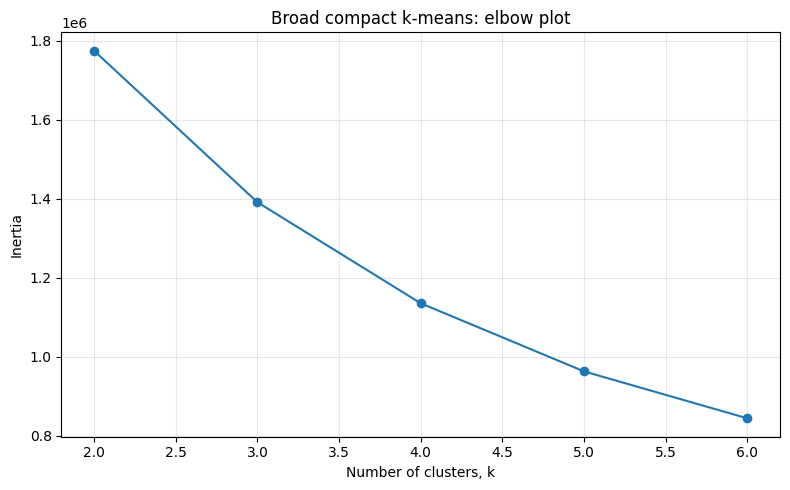

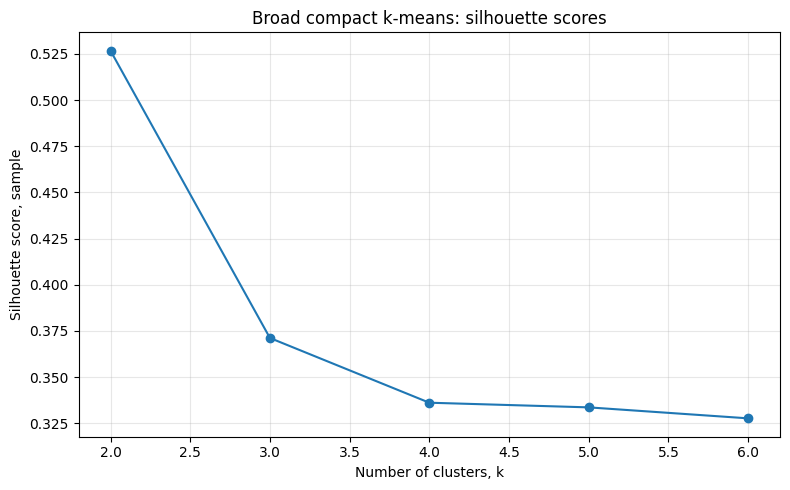

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(results["k"], results["inertia"], marker="o")
plt.xlabel("Number of clusters, k")
plt.ylabel("Inertia")
plt.title("Broad compact k-means: elbow plot")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(results["k"], results["silhouette_sample"], marker="o")
plt.xlabel("Number of clusters, k")
plt.ylabel("Silhouette score, sample")
plt.title("Broad compact k-means: silhouette scores")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Cell 7 — Run final models for selected k values

In [12]:
selected_k_values = [2, 3, 4, 5, 6]

In [13]:
selected_k_values = [2, 3, 4, 5, 6]

for k in selected_k_values:
    print(f"Running final broad compact k-means for k={k}")

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50,
        max_iter=500
    )

    labels = model.fit_predict(X_scaled_df)

    # 1-based labels for mapping
    km_gdf[f"bkm{k}"] = pd.Series(index=km_gdf.index, dtype="Int64")
    km_gdf.loc[valid_mask, f"bkm{k}"] = labels + 1

print(km_gdf[[f"bkm{k}" for k in selected_k_values]].head())

Running final broad compact k-means for k=2
Running final broad compact k-means for k=3
Running final broad compact k-means for k=4
Running final broad compact k-means for k=5
Running final broad compact k-means for k=6
   bkm2  bkm3  bkm4  bkm5  bkm6
0     1     2     4     1     3
1     2     2     2     3     1
2     2     1     2     3     5
3     1     2     4     1     1
4     1     2     4     1     3


# Cell 8 — Cluster profile tables

In [14]:
profile_vars = [
    "d20_near",
    "d80_near",
    "d500_near",
    "d2000_near",
    "d8000_near",
    "r8000_80",
]

for k in selected_k_values:
    label_col = f"bkm{k}"

    median_profile = (
        km_gdf.loc[valid_mask]
        .groupby(label_col)[profile_vars]
        .median()
        .round(3)
    )

    counts = km_gdf.loc[valid_mask][label_col].value_counts().sort_index()
    shares = counts / counts.sum()

    median_profile.insert(0, "count", counts)
    median_profile.insert(1, "share", shares.round(4))

    print("\n" + "=" * 90)
    print(f"Broad compact median cluster profile for k={k}")
    display(median_profile)

    out_csv = os.path.join(
        profile_folder,
        f"broad_compact_kmeans_k{k}_median_profile.csv"
    )

    median_profile.to_csv(out_csv)
    print("Exported:", out_csv)


Broad compact median cluster profile for k=2


,count,share,d20_near,d80_near,d500_near,d2000_near,d8000_near,r8000_80
bkm2,,,,,,,,
1,139802,0.2417,64.588,133.203,340.700,714.782,1470.249,10.679
2,438577,0.7583,34.283,70.703,182.962,377.145,780.062,11.134


Exported: E:\World Bank deliverbale 1\knn\kmeans_profiles_broad_compact\broad_compact_kmeans_k2_median_profile.csv

Broad compact median cluster profile for k=3


,count,share,d20_near,d80_near,d500_near,d2000_near,d8000_near,r8000_80
bkm3,,,,,,,,
1,317657,0.5492,31.655,66.050,172.185,357.691,745.494,11.361
2,187556,0.3243,47.140,95.277,243.252,497.028,1019.815,10.461
3,73166,0.1265,77.509,163.392,425.959,883.590,1762.515,10.724


Exported: E:\World Bank deliverbale 1\knn\kmeans_profiles_broad_compact\broad_compact_kmeans_k3_median_profile.csv

Broad compact median cluster profile for k=4


...

Exported: E:\World Bank deliverbale 1\knn\kmeans_profiles_broad_compact\broad_compact_kmeans_k4_median_profile.csv

Broad compact median cluster profile for k=5


,count,share,d20_near,d80_near,d500_near,d2000_near,d8000_near,r8000_80
bkm5,,,,,,,,
1,138440,0.2394,48.412,97.484,245.544,496.624,1016.179,10.154
2,75045,0.1298,24.584,52.313,146.404,342.339,826.897,15.669
3,269459,0.4659,33.854,69.694,178.596,363.970,744.446,10.822
4,68718,0.1188,62.392,130.926,351.660,768.496,1618.189,12.633
5,26717,0.0462,111.845,235.986,572.727,1070.094,1941.682,7.798


Exported: E:\World Bank deliverbale 1\knn\kmeans_profiles_broad_compact\broad_compact_kmeans_k5_median_profile.csv

Broad compact median cluster profile for k=6


,count,share,d20_near,d80_near,d500_near,d2000_near,d8000_near,r8000_80
bkm6,,,,,,,,
1,147829,0.2556,45.325,91.638,231.540,469.598,978.213,10.488
2,68567,0.1186,24.216,51.570,144.542,339.317,828.425,15.851
3,47365,0.0819,76.303,155.167,368.658,693.421,1312.975,8.626
4,14846,0.0257,124.970,288.692,780.405,1471.476,2608.038,8.829
5,247065,0.4272,33.180,68.431,175.691,358.839,734.711,10.858
6,52707,0.0911,58.286,121.847,334.844,774.837,1668.498,13.660


Exported: E:\World Bank deliverbale 1\knn\kmeans_profiles_broad_compact\broad_compact_kmeans_k6_median_profile.csv


# Cell 9 — Optional PCA diagnostic plot

Explained variance ratio: [0.74931038 0.21738141]


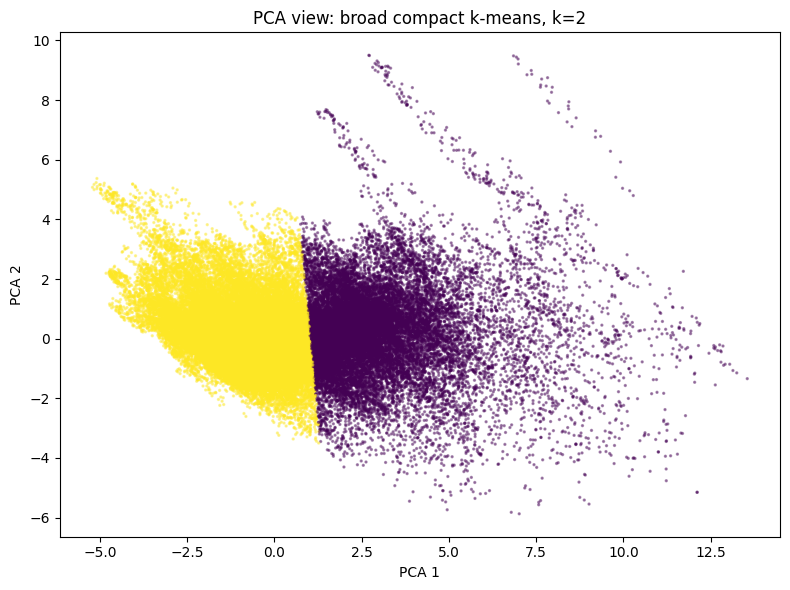

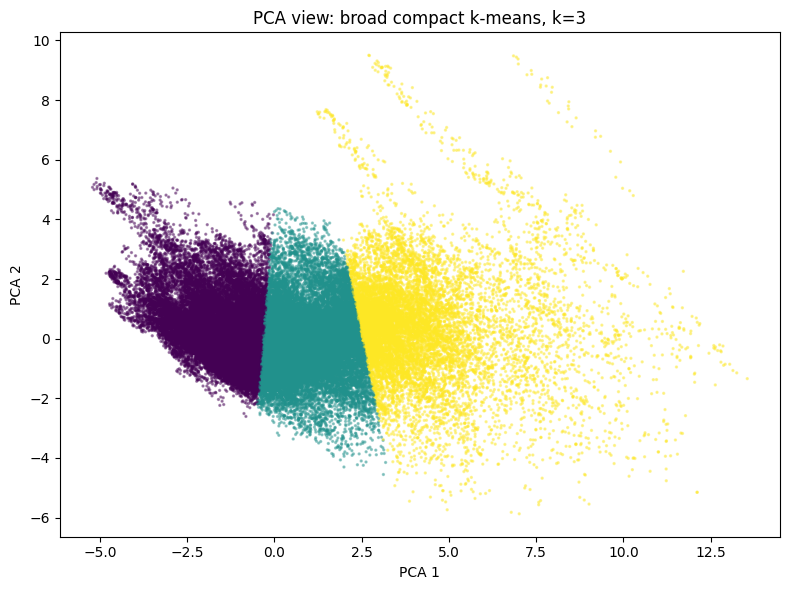

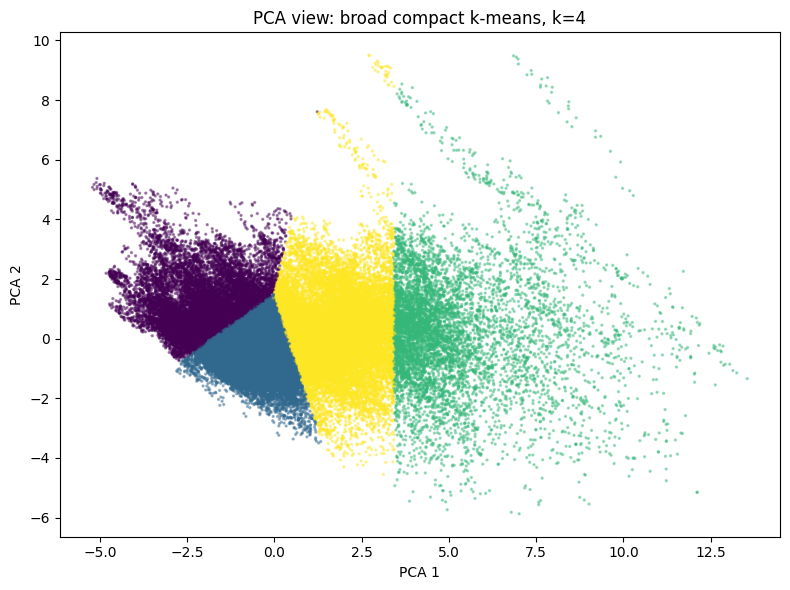

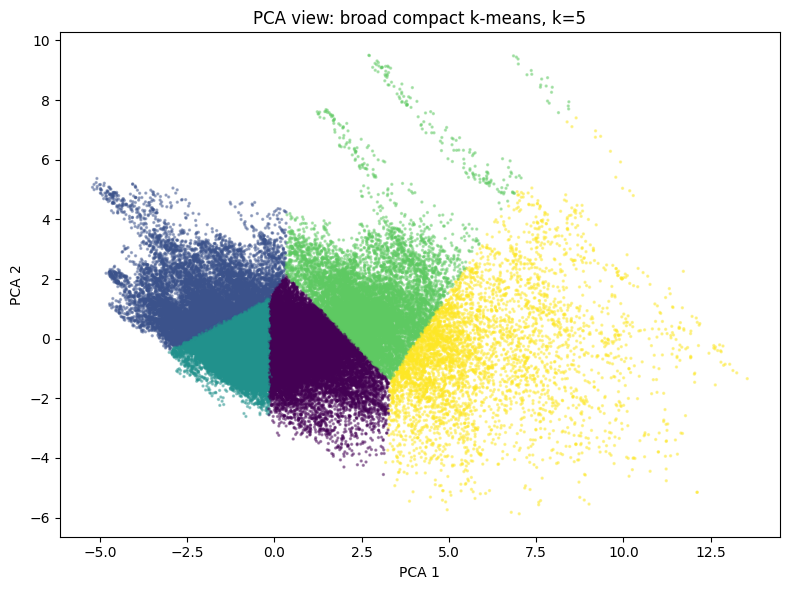

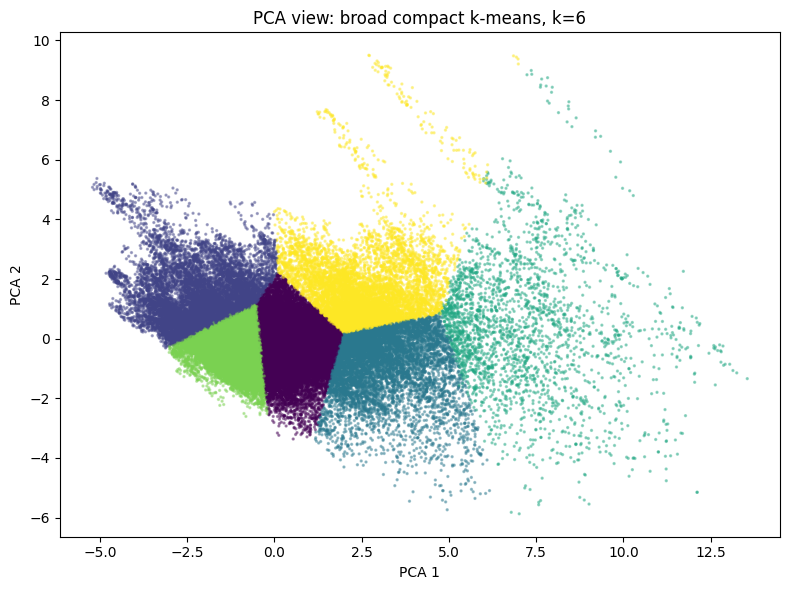

In [16]:
plot_sample_size = 100_000

if len(X_scaled_df) > plot_sample_size:
    sample_idx = X_scaled_df.sample(plot_sample_size, random_state=42).index
else:
    sample_idx = X_scaled_df.index

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_df.loc[sample_idx])

print("Explained variance ratio:", pca.explained_variance_ratio_)

for k in selected_k_values:
    label_col = f"bkm{k}"
    labels_sample = km_gdf.loc[sample_idx, label_col]

    plt.figure(figsize=(8, 6))
    plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=labels_sample,
        s=2,
        alpha=0.4
    )
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"PCA view: broad compact k-means, k={k}")
    plt.tight_layout()
    plt.show()

# Cell 10 — Export new GeoPackage for ArcGIS

In [15]:
# Remove old output if it exists
if os.path.exists(out_gpkg):
    os.remove(out_gpkg)

out_layer = "wb_buildings_knn_broad_compact_kmeans"

keep_cols = [
    "type",
    "building",
    "construction",
    "area_m_utm",
    "ORIG_FID",
    "building_id",
    "d5_near",
    "d20_near",
    "d80_near",
    "d500_near",
    "d1000_near",
    "d2000_near",
    "d4000_near",
    "d8000_near",
    "r80_5",
    "r500_80",
    "r1000_80",
    "r2000_80",
    "r4000_80",
    "r8000_80",
    "log_d20",
    "log_d80",
    "log_d500",
    "log_d2000",
    "log_d8000",
    "log_r8000_80",
] + [f"bkm{k}" for k in selected_k_values] + ["geometry"]

keep_cols = [c for c in keep_cols if c in km_gdf.columns]

export_gdf = km_gdf[keep_cols].copy()

export_gdf.to_file(out_gpkg, layer=out_layer, driver="GPKG")

print("Exported:")
print(out_gpkg)
print("Layer:", out_layer)
print("Rows:", f"{len(export_gdf):,}")
print("Columns:")
print(export_gdf.columns.tolist())

Exported:
E:\World Bank deliverbale 1\knn\buildings_points_knn_kmeans_broad_compact.gpkg
Layer: wb_buildings_knn_broad_compact_kmeans
Rows: 578,379
Columns:
['type', 'building', 'construction', 'area_m_utm', 'ORIG_FID', 'building_id', 'd5_near', 'd20_near', 'd80_near', 'd500_near', 'd1000_near', 'd2000_near', 'd4000_near', 'd8000_near', 'r80_5', 'r500_80', 'r1000_80', 'r2000_80', 'r4000_80', 'r8000_80', 'log_d20', 'log_d80', 'log_d500', 'log_d2000', 'log_d8000', 'log_r8000_80', 'bkm2', 'bkm3', 'bkm4', 'bkm5', 'bkm6', 'geometry']


In [17]:
import arcpy
import os

# ------------------------------------------------------------
# Inputs
# ------------------------------------------------------------

gdb = r"E:\World Bank deliverbale 1\knn\New File Geodatabase.gdb"

near_table = os.path.join(gdb, "_179992_example")

buildings_fc = r"E:\World Bank deliverbale 1\wb_buildings\buildings_points_utm.gdb\buildings_points"

out_fc = os.path.join(gdb, "_179992_near_features")

near_field = "NEAR_FID"
building_oid_field = "OBJECTID"

# ------------------------------------------------------------
# Environment
# ------------------------------------------------------------

arcpy.env.overwriteOutput = True

# ------------------------------------------------------------
# Collect NEAR_FID values
# ------------------------------------------------------------

near_ids = set()

with arcpy.da.SearchCursor(near_table, [near_field]) as cursor:
    for row in cursor:
        val = row[0]
        if val is not None and val != -1:
            near_ids.add(int(val))

print(f"Found {len(near_ids):,} unique NEAR_FID values.")

if not near_ids:
    raise ValueError("No valid NEAR_FID values found.")

# ------------------------------------------------------------
# Select matching building features
# ------------------------------------------------------------

buildings_lyr = "buildings_lyr"

if arcpy.Exists(buildings_lyr):
    arcpy.management.Delete(buildings_lyr)

arcpy.management.MakeFeatureLayer(buildings_fc, buildings_lyr)

# ArcGIS SQL IN clauses can get too long, so select in chunks
chunk_size = 900
near_ids_list = sorted(near_ids)

first_selection = True
selected_total = 0

for i in range(0, len(near_ids_list), chunk_size):
    chunk = near_ids_list[i:i + chunk_size]

    sql = f"{arcpy.AddFieldDelimiters(buildings_fc, building_oid_field)} IN ({','.join(map(str, chunk))})"

    selection_type = "NEW_SELECTION" if first_selection else "ADD_TO_SELECTION"

    arcpy.management.SelectLayerByAttribute(
        buildings_lyr,
        selection_type,
        sql
    )

    first_selection = False

selected_total = int(arcpy.management.GetCount(buildings_lyr)[0])
print(f"Selected {selected_total:,} building features.")

# ------------------------------------------------------------
# Export selected buildings
# ------------------------------------------------------------

if arcpy.Exists(out_fc):
    arcpy.management.Delete(out_fc)

arcpy.management.CopyFeatures(buildings_lyr, out_fc)

print(f"Exported selected buildings to:")
print(out_fc)

ModuleNotFoundError: No module named 'arcpy'